### Importing Libraries
Importing essential data manipulation (`pandas`) and numerical computing (`numpy`) libraries.

In [65]:
import pandas as pd
import numpy as np

### 1. Data Loading and Inspection
Loading the **Real Estate Valuation dataset**

In [66]:
df = pd.read_excel("../Datasets/Real_estate_valuation.xlsx")

In [67]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


### Column Renaming
Renaming raw dataset columns to clean, standardized snake_case identifiers to streamline matrix operations.

In [68]:
df = df.rename(columns={"X1 transaction date" : "transaction_date",
                        "X2 house age":"house_age",
                        "X3 distance to the nearest MRT station": "distance_to_mrt_station",
                        "X4 number of convenience stores": "no_of_convenience_stores",
                        "X5 latitude" : "latitude",
                        "X6 longitude" : "longitude",
                        "Y house price of unit area" : "Y_house_price_unit_area"})
df.head()

,No,transaction_date,house_age,distance_to_mrt_station,no_of_convenience_stores,latitude,longitude,Y_house_price_unit_area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


### 2. Feature Extraction & Target Separation
Separating the input feature matrix $X$ from the target variable vector $Y$ (`Y_house_price_unit_area`) and reshaping $Y$ into a 2D column vector of shape `(414, 1)` for matrix multiplication compatibility.

In [69]:
X = df.drop("Y_house_price_unit_area",axis=1).to_numpy()
Y = df["Y_house_price_unit_area"].to_numpy().reshape(-1,1)
print(Y.shape)


(414, 1)


### Initializing Parameters
Defining the parameter initialization function to randomly generate the weight vector $W$ and bias term $b$.

In [70]:
def intialize_params(X):
    W = np.random.randn(X.shape[1],1)
    b = np.random.randn(1,1)
    return W, b

### Data Normalization
Implementing **Z-score normalization** to scale features and target values, stabilizing gradient descent optimization:
$$X_{scaled} = \frac{X - \mu}{\sigma}$$

In [71]:
def normalizing_data(X,Y):
    X_Scaled = (X - np.mean(X,axis=0, keepdims=True)) / np.std(X,axis=0,keepdims=True)
    Y_Scaled = (Y - np.mean(Y)) / np.std(Y)

    return X_Scaled, Y_Scaled

### Predict Function
Implementing the linear model prediction hypothesis using matrix multiplication:
$$\hat{Y} = XW + b$$

In [72]:
def predict(X,W,b):
    return X@W +b

### Cost Function (L1 Regularization - Lasso)
Computing the regularized cost using Mean Squared Error (MSE) combined with an **L1 Regularization penalty** ($\lambda \sum |W|$), which penalizes absolute weights and drives irrelevant feature coefficients to zero:
$$J(W, b) = \frac{1}{2n} \sum (\hat{Y} - Y)^2 + \frac{\lambda}{n} \sum |W|$$

In [73]:
def compute_cost(Y,Y_hat,lamda,W):
    n = Y.shape[0]
    return (1/(2*n))*np.sum((Y_hat - Y)**2) + ((lamda)*np.sum(np.abs(W)))

### Gradient Calculations
Calculating the analytical partial derivatives of the cost function with respect to weights ($dEdw$) and bias ($dEdb$), including the L1 penalty derivative term via `np.sign(W)`.

$$\frac{\partial J}{\partial W} = \frac{1}{n} X^T (\hat{Y} - Y) + \frac{\lambda}{n} \text{sign}(W)$$
$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum (\hat{Y} - Y)$$

In [74]:
def dEdw(X,Y,W,b,lamda):
    n = X.shape[0]
    Y_hat = predict(X,W,b)

    return (np.dot(X.T,Y_hat- Y)) / n + (lamda/n) * np.sign(W)
def dEdb(Y,W,X,b):
    Y_hat = predict(X,W,b)
    n = Y.shape[0]

    return np.sum(Y_hat -  Y) / n



### Gradient Descent Training Loop
Iterating through the specified epochs to perform gradient descent updates on weights and biases while tracking training loss convergence.

In [98]:
def train(X,Y,W,b,learning_rate = 0.1, lamda = 1, epochs = 250):
    losses = []

    for epoch in range(epochs):
        dw = dEdw(X,Y,W,b,lamda)
        db = dEdb(Y,W,X,b)

        W = W - learning_rate * dw
        b = b - learning_rate * db

        Y_hat = predict(X,W,b)
        losses.append(compute_cost(Y,Y_hat,lamda,W))

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch}: Loss {losses[-1]}")
    return W, b, losses

### Procedural Training & Execution
Normalizing the dataset, initializing parameters, and running the procedural training loop to minimize regularized loss across epochs.

In [99]:
X_norm, Y_norm  = normalizing_data(X, Y)
W,b = intialize_params(X)
W


array([[-1.01378452],
       [ 1.24265942],
       [ 2.27334157],
       [ 0.07159984],
       [-0.85613047],
       [ 1.64283776],
       [ 0.74192093]])

In [100]:
W,b,losses= train(X_norm, Y_norm, W, b)

Epoch 0: Loss 13.334413532962213
Epoch 10: Loss 4.222773148666975
Epoch 20: Loss 1.8827922781736437
Epoch 30: Loss 1.4571690119280918
Epoch 40: Loss 1.446415843026412
Epoch 50: Loss 1.4440567692608028
Epoch 60: Loss 1.4416147385762825
Epoch 70: Loss 1.4386101888189335
Epoch 80: Loss 1.4354439309298264
Epoch 90: Loss 1.432420644257463
Epoch 100: Loss 1.429686641964696
Epoch 110: Loss 1.427287412696648
Epoch 120: Loss 1.425216783252602
Epoch 130: Loss 1.4234459858227644
Epoch 140: Loss 1.4219387944643764
Epoch 150: Loss 1.4206587768855417
Epoch 160: Loss 1.4195724287378146
Epoch 170: Loss 1.4186502599538777
Epoch 180: Loss 1.4178669122237215
Epoch 190: Loss 1.4172008543445558
Epoch 200: Loss 1.4166339253690015
Epoch 210: Loss 1.4161508537730676
Epoch 220: Loss 1.4167655860721204
Epoch 230: Loss 1.4173108021933936
Epoch 240: Loss 1.416928306149263
Epoch 249: Loss 1.4169975822597665


In [101]:
W

array([[-2.87647230e-02],
       [ 1.02395761e-01],
       [-2.24117148e-01],
       [-4.01334557e-01],
       [ 2.45330056e-01],
       [ 2.06553936e-01],
       [-1.30904423e-04]])

### Visulization of House data

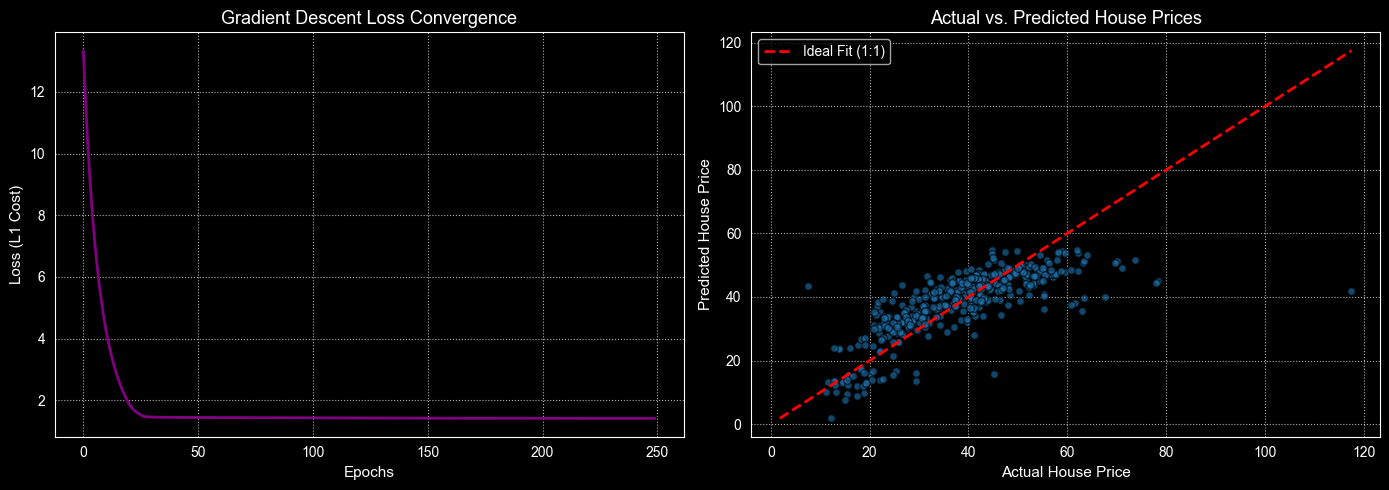

In [102]:
import matplotlib.pyplot as plt

# Generate predictions back on the original scale using normalized features
Y_pred_norm = predict(X_norm, W, b)
Y_pred_original = (Y_pred_norm * np.std(Y)) + np.mean(Y)

# Create a clean two-panel evaluation figure for standard Linear/Lasso Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Convergence Curve
axes[0].plot(losses, color='purple', linewidth=2)
axes[0].set_xlabel('Epochs', fontsize=11)
axes[0].set_ylabel('Loss (L1 Cost)', fontsize=11)
axes[0].set_title('Gradient Descent Loss Convergence', fontsize=13)
axes[0].grid(True, linestyle=':', alpha=0.7)

# Plot 2: Actual vs. Predicted Target Distribution
Y_actual = Y.ravel()
Y_predicted = Y_pred_original.ravel()

axes[1].scatter(Y_actual, Y_predicted, color='#1f77b4', alpha=0.6, edgecolors='k', s=30)
min_val = min(Y_actual.min(), Y_predicted.min())
max_val = max(Y_actual.max(), Y_predicted.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (1:1)')

axes[1].set_xlabel('Actual House Price', fontsize=11)
axes[1].set_ylabel('Predicted House Price', fontsize=11)
axes[1].set_title('Actual vs. Predicted House Prices', fontsize=13)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Polynomial Feature Expansion & External Pipeline Execution
Appending the project directory to Python's path to import custom modules, generating degree-3 polynomial features, standardizing them, and fitting the regression model.

In [110]:
import sys
import os

# Add the root project directory to Python's path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../')))

from PolynomialRegression.poly_model import PolynomialRegression
from LassoRegression import LassoRegression

poly = PolynomialRegression()
poly_features = poly.PolynomialFeatures(X)
poly_features.shape
poly_scaled = (poly_features - np.mean(poly_features,axis = 0,keepdims=True)) / np.std(poly_features,axis = 0,keepdims=True)
lasso = LassoRegression(lamda = 1, learning_rate=0.01, epochs=10000)
lasso.fit(poly_scaled,Y_norm)
lasso.W



Cost after epoch 0: 6.0221119984588105
Cost after epoch 50: 0.8744134754496302
Cost after epoch 100: 0.55247853377831
Cost after epoch 150: 0.4608846560472217
Cost after epoch 200: 0.41319168091085984
Cost after epoch 250: 0.3805017691357962
Cost after epoch 300: 0.35615988523096076
Cost after epoch 350: 0.3374639091985908
Cost after epoch 400: 0.3228005326085715
Cost after epoch 450: 0.31106568124555317
Cost after epoch 500: 0.3014760896782558
Cost after epoch 550: 0.2934706384236968
Cost after epoch 600: 0.28664589378999866
Cost after epoch 650: 0.2807111092853484
Cost after epoch 700: 0.2755993352213022
Cost after epoch 750: 0.27113918444350577
Cost after epoch 800: 0.267065651567245
Cost after epoch 850: 0.2633045701865206
Cost after epoch 900: 0.25980139831279137
Cost after epoch 950: 0.2565156717961511
Cost after epoch 1000: 0.2534170631535895
Cost after epoch 1050: 0.2504825597722507
Cost after epoch 1100: 0.2476944414489744
Cost after epoch 1150: 0.24503882987770717
Cost after 

array([[-2.61830929e-02],
       [ 6.23892517e-01],
       [-8.03413086e-01],
       [-9.51285868e-01],
       [ 3.27045230e-02],
       [ 2.24698013e-01],
       [-7.55162381e-01],
       [ 6.25383492e-06],
       [-4.99994320e-01],
       [ 5.88581032e-01],
       [ 5.90703941e-01],
       [ 1.07156656e-01],
       [ 8.25340288e-06],
       [ 7.77757269e-01]])

### 5. Model Evaluation & Visualization
We visualize our trained Lasso Polynomial Regression model by plotting the gradient descent loss convergence over epochs and comparing our actual house prices against the model's predictions.

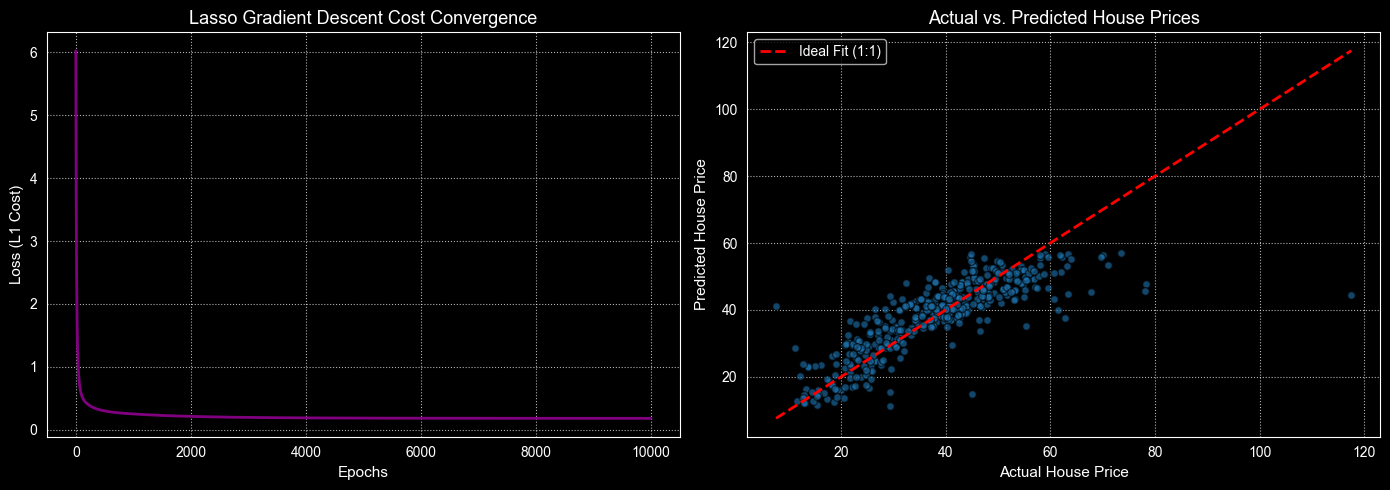

In [111]:
import matplotlib.pyplot as plt

# Generate predictions back on the original scale
Y_pred_lasso = lasso.LinearModel(poly_scaled)
Y_pred_original = (Y_pred_lasso * np.std(Y)) + np.mean(Y)

# Create a clean two-panel evaluation figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Convergence Curve
axes[0].plot(lasso.losses, color='purple', linewidth=2)
axes[0].set_xlabel('Epochs', fontsize=11)
axes[0].set_ylabel('Loss (L1 Cost)', fontsize=11)
axes[0].set_title('Lasso Gradient Descent Cost Convergence', fontsize=13)
axes[0].grid(True, linestyle=':', alpha=0.7)

# Plot 2: Actual vs. Predicted Target Distribution
Y_actual = Y.ravel()
Y_predicted = Y_pred_original.ravel()

axes[1].scatter(Y_actual, Y_predicted, color='#1f77b4', alpha=0.6, edgecolors='k', s=30)
min_val = min(Y_actual.min(), Y_predicted.min())
max_val = max(Y_actual.max(), Y_predicted.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (1:1)')

axes[1].set_xlabel('Actual House Price', fontsize=11)
axes[1].set_ylabel('Predicted House Price', fontsize=11)
axes[1].set_title('Actual vs. Predicted House Prices', fontsize=13)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()